
# ============================================================
# 1. SETUP & DATA LOADING
# ============================================================

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# For Persian text visualization (if needed)
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
except:
    pass


In [ ]:

# # Load dataset from Hugging Face
# from datasets import load_dataset

# print("Loading dataset from Hugging Face...")

# dataset = load_dataset(
#     "aliqnbri/reviews",
#     data_files={
#         "train": "train_data.csv",
#         "test": "test_data.csv",
#         "title_brand": "title_brand.csv"
#     }
# )

# # Convert to pandas DataFrames
# train_df = pd.DataFrame(dataset['train'])
# test_df = pd.DataFrame(dataset['test'])
# product_mapping_df = pd.DataFrame(dataset['title_brand'])

In [3]:

# Convert to pandas DataFrames
train_df = pd.read_csv("dataset/train_data.csv")
test_df  = pd.read_csv("dataset/test_data.csv")
product_mapping_df = pd.read_csv("dataset/title_brand.csv")


In [4]:

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape if test_df is not None else 'N/A'}")
print(f"\nTrain columns: {train_df.columns.tolist()}")
print(f"\nFirst few rows:")
print(train_df.head())

Train shape: (838944, 11)
Test shape: (20000, 10)

Train columns: ['overall', 'vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime']

First few rows:
   overall vote  verified  reviewTime      reviewerID        asin style  \
0        2  NaN     False  2016-11-11   A2OSUEZJIN7BI  0511189877   NaN   
1        5  NaN      True  2016-06-06  A2NETQRG6JHIG7  0511189877   NaN   
2        4  NaN      True  2016-03-10  A12JHGROAX49G7  0511189877   NaN   
3        5  NaN      True  2016-01-14  A1KV65E2TMMG6F  0511189877   NaN   
4        5  NaN      True  2016-10-20  A280POPEWI0NSA  0594459451   NaN   

    reviewerName                                         reviewText  \
0          Chris  I have an older URC-WR7 remote and thought thi...   
1   Qrysta White  First time I've EVER had a remote that needed ...   
2        Linwood  Got them and only 2 of them worked. company ca...   
3  Dane Williams  I got tired of the remote be

In [5]:

# Basic info
print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
train_df.info()
print("\nMissing values:")
print(train_df.isnull().sum())
print("\nBasic statistics:")
print(train_df.describe())


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838944 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838944 non-null  int64 
 1   vote            191468 non-null  object
 2   verified        838944 non-null  bool  
 3   reviewTime      838944 non-null  object
 4   reviewerID      838944 non-null  object
 5   asin            838944 non-null  object
 6   style           490613 non-null  object
 7   reviewerName    838717 non-null  object
 8   reviewText      838944 non-null  object
 9   summary         838868 non-null  object
 10  unixReviewTime  838944 non-null  int64 
dtypes: bool(1), int64(2), object(8)
memory usage: 64.8+ MB

Missing values:
overall                0
vote              647476
verified               0
reviewTime             0
reviewerID             0
asin                   0
style             348331
reviewerName         227
review


# ============================================================
# 2. PART 1: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================


[Q1] Distribution of Overall Ratings
--------------------------------------------------

Rating distribution:
overall
1     82950
2     56756
3     81239
4    156514
5    461485
Name: count, dtype: int64



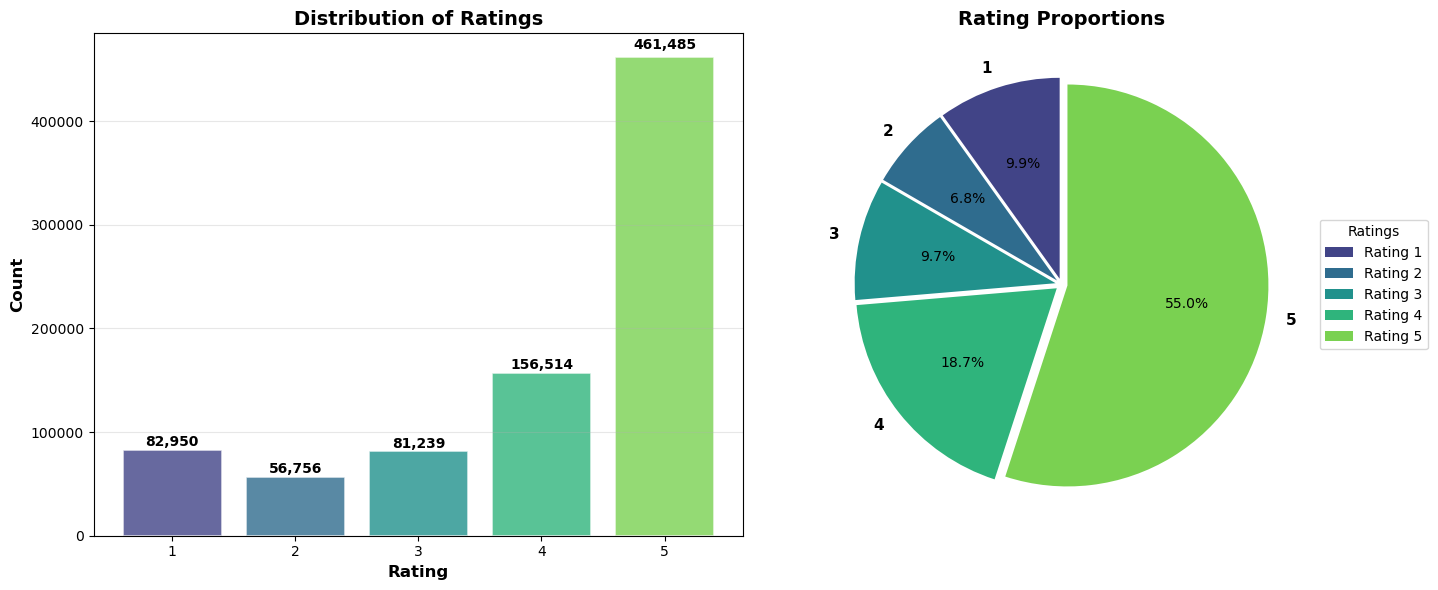

In [6]:

# ------------------------------------------------------------
# Question 1: Distribution of 'overall' ratings
# ------------------------------------------------------------
print("\n[Q1] Distribution of Overall Ratings")
print("-" * 50)

rating_counts = train_df['overall'].value_counts().sort_index()
print(f"\nRating distribution:\n{rating_counts}\n")


# Create figure with adjusted subplot spacing
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
fig.subplots_adjust(wspace=0.3)  # Increased gap between subplots

# Get Viridis color palette
viridis_colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(rating_counts)))

# Bar plot with Viridis colors
bars = ax[0].bar(rating_counts.index, rating_counts.values, 
                 color=viridis_colors, alpha=0.8, edgecolor='white', linewidth=1.2)
ax[0].set_xlabel('Rating', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Count', fontsize=12, fontweight='bold')
ax[0].set_title('Distribution of Ratings', fontsize=14, fontweight='bold')
ax[0].grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
               f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

# Pie chart with Viridis colors and gap between slices (flat, no 3D)
wedges, texts, autotexts = ax[1].pie(rating_counts.values, 
                                    labels=rating_counts.index, 
                                    autopct='%1.1f%%', 
                                    colors=viridis_colors, 
                                    startangle=90,
                                    explode=[0.03] * len(rating_counts),  # Small gap between slices
                                    textprops={'fontsize': 11, 'fontweight': 'bold'})

# Improve autopct text appearance
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('normal')
    autotext.set_fontsize(10)

ax[1].set_title('Rating Proportions', fontsize=14, fontweight='bold')

# Add legend for better readability
ax[1].legend(wedges, [f'Rating {i}' for i in rating_counts.index],
            title="Ratings",
            loc="center left",
            bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()






In [7]:
# Check if dataset is balanced
print("\nBalance Analysis:")


# Check balance ratio
imbalance_ratio = rating_counts.max() / rating_counts.min()


print(f"Most common rating: {rating_counts.idxmax()} ({rating_counts.max()} samples)")
print(f"Least common rating: {rating_counts.idxmin()} ({rating_counts.min()} samples)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}x")


if imbalance_ratio > 1.5:
    print("\n⚠️  Dataset is IMBALANCED!")
    print("\nRecommended solutions:")
    print("1. Class weighting in loss function")
    print("2. Oversampling minority classes (SMOTE)")
    print("3. Undersampling majority class")
    print("4. Focal Loss for handling imbalance")
    print("5. Data augmentation for minority classes")
else:
    print("\n✓ Dataset is reasonably balanced")


Balance Analysis:
Most common rating: 5 (461485 samples)
Least common rating: 2 (56756 samples)
Imbalance ratio: 8.13x

⚠️  Dataset is IMBALANCED!

Recommended solutions:
1. Class weighting in loss function
2. Oversampling minority classes (SMOTE)
3. Undersampling majority class
4. Focal Loss for handling imbalance
5. Data augmentation for minority classes



# ------------------------------------------------------------
# Question 2: Word Clouds for Positive, Neutral, Negative
# ------------------------------------------------------------

In [13]:
# Define sentiment categories
train_df["sentiment"] = train_df["overall"].apply(
    lambda x: "Positive" if x >= 4 else ("Neutral" if x == 3 else "Negative")
)


print("\nSentiment distribution:")
sentiment_counts = train_df["sentiment"].value_counts()
print(sentiment_counts)


Sentiment distribution:
sentiment
Positive    617999
Negative    139706
Neutral      81239
Name: count, dtype: int64


In [9]:
# English stop words (extended list for reviews)
from nltk.corpus import stopwords
import nltk

try:
    stop_words = set(stopwords.words("english"))
except:
    nltk.download("stopwords")
    stop_words = set(stopwords.words("english"))

# Add custom stop words common in reviews
custom_stop_words = {
    "product",
    "item",
    "one",
    "get",
    "use",
    "like",
    "would",
    "good",
    "amazon",
    "purchased",
    "buy",
    "bought",
    "great",
    "really",
    "well",
    "also",
    "much",
    "even",
    "work",
    "works",
    "working",
    "used",
    "review",
    "thing",
    "make",
    "could",
    "made",
    "order",
    "price",
    "quality",
    "time",
    "things",
    "go",
    "going",
    "back",
    "got",
    "say",
    "said",
    "know",
    "look",
    "looking",
    "looks",
    "see",
    "seeing",
    "come",
    "comes",
    "take",
    "took",
    "think",
    "thought",
    "feel",
    "feels",
    "felt",
    "want",
    "wanted",
    "need",
    "needed",
    "give",
    "gave",
    "find",
    "found",
    "tell",
    "told",
    "try",
    "tried",
    "better",
    "best",
    "nice",
    "excellent",
    "perfect",
    "awesome",
    "bad",
    "terrible",
    "horrible",
    "awful",
    "worst",
    "waste",
    "disappointed",
}

stop_words.update(custom_stop_words)

In [10]:

def clean_text_for_wordcloud(text):
    """Clean text for word cloud generation"""
    import re
    if pd.isna(text):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove special characters but keep spaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Remove extra spaces
    text = ' '.join(text.split())
    return text

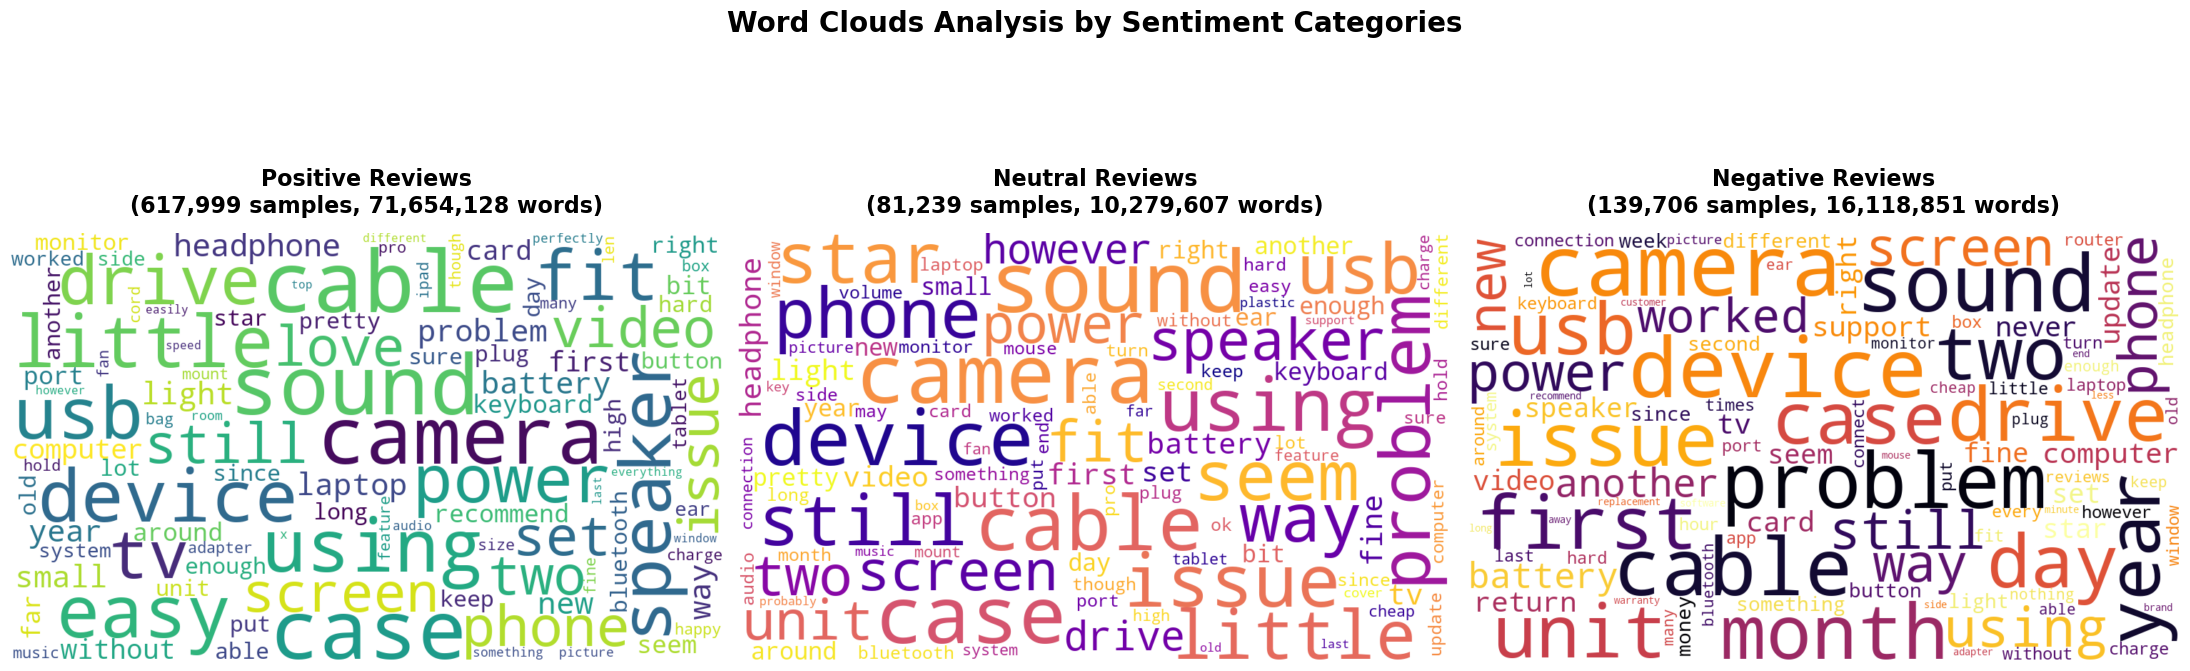

In [11]:

# Generate enhanced word clouds
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
sentiments = ['Positive', 'Neutral', 'Negative']
colors_wc = ['viridis', 'plasma', 'inferno']  

# Store word frequencies for analysis
word_frequencies = {}

for idx, (sentiment, color) in enumerate(zip(sentiments, colors_wc)):
    reviews = train_df.loc[train_df['sentiment'] == sentiment, 'reviewText'].dropna()
    
    if len(reviews) == 0:
        print(f"No reviews found for {sentiment} sentiment")
        continue
        
    all_text = ' '.join(reviews.apply(clean_text_for_wordcloud))
    
    # Generate word cloud with enhanced settings
    wordcloud = WordCloud(
        width=1000, 
        height=600,
        background_color='white',
        stopwords=stop_words,
        max_words=100,  # Reduced for better readability
        colormap=color,
        contour_color='steelblue',
        contour_width=1,
        relative_scaling=0.4,  # Better size variation
        min_font_size=8,
        max_font_size=120,
        random_state=42,  # For reproducible results
        collocations=False  # Avoid word pairs for cleaner visualization
    ).generate(all_text)
    
    # Store word frequencies for comparison
    word_frequencies[sentiment] = wordcloud.words_
    
    # Plot with enhanced styling
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'{sentiment} Reviews\n({len(reviews):,} samples, {len(all_text.split()):,} words)',
                        fontsize=16, fontweight='bold', pad=15)
    axes[idx].axis('off')
    
    # Add border to each subplot
    for spine in axes[idx].spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('lightgray')
        spine.set_linewidth(1)

plt.suptitle("Word Clouds Analysis by Sentiment Categories", 
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [14]:

# Analyze common words between positive and negative sentiments
print("\n" + "="*60)
print("ANALYSIS OF COMMON WORDS BETWEEN POSITIVE AND NEGATIVE SENTIMENTS")
print("="*60)

if 'Positive' in word_frequencies and 'Negative' in word_frequencies:
    positive_words = set(word_frequencies['Positive'].keys())
    negative_words = set(word_frequencies['Negative'].keys())
    
    common_words = positive_words.intersection(negative_words)
    
    print(f"\nNumber of common words between Positive and Negative: {len(common_words)}")
    
    if common_words:
        print("\nTop 20 common words (present in both positive and negative reviews):")
        # Sort by combined frequency
        common_word_scores = {}
        for word in common_words:
            pos_freq = word_frequencies['Positive'].get(word, 0)
            neg_freq = word_frequencies['Negative'].get(word, 0)
            common_word_scores[word] = pos_freq + neg_freq
        
        # Display top 20 common words
        for i, (word, score) in enumerate(sorted(common_word_scores.items(), 
                                               key=lambda x: x[1], reverse=True)[:20]):
            pos_freq = word_frequencies['Positive'].get(word, 0)
            neg_freq = word_frequencies['Negative'].get(word, 0)
            print(f"{i+1:2d}. {word:15s} | Pos: {pos_freq:.4f} | Neg: {neg_freq:.4f} | Total: {score:.4f}")

# Additional statistics
print("\n" + "="*60)
print("SENTIMENT ANALYSIS SUMMARY")
print("="*60)
print(f"Total reviews: {len(train_df):,}")
print(f"Positive reviews (4-5 stars): {sentiment_counts.get('Positive', 0):,}")
print(f"Neutral reviews (3 stars): {sentiment_counts.get('Neutral', 0):,}")
print(f"Negative reviews (1-2 stars): {sentiment_counts.get('Negative', 0):,}")


ANALYSIS OF COMMON WORDS BETWEEN POSITIVE AND NEGATIVE SENTIMENTS

Number of common words between Positive and Negative: 71

Top 20 common words (present in both positive and negative reviews):
 1. cable           | Pos: 1.0000 | Neg: 0.8404 | Total: 1.8404
 2. camera          | Pos: 0.8182 | Neg: 1.0000 | Total: 1.8182
 3. sound           | Pos: 0.9219 | Neg: 0.8216 | Total: 1.7435
 4. device          | Pos: 0.6379 | Neg: 0.9215 | Total: 1.5594
 5. case            | Pos: 0.8984 | Neg: 0.6344 | Total: 1.5327
 6. using           | Pos: 0.6723 | Neg: 0.6036 | Total: 1.2759
 7. usb             | Pos: 0.6465 | Neg: 0.6194 | Total: 1.2660
 8. drive           | Pos: 0.5485 | Neg: 0.6873 | Total: 1.2358
 9. problem         | Pos: 0.4419 | Neg: 0.7642 | Total: 1.2061
10. issue           | Pos: 0.4897 | Neg: 0.7099 | Total: 1.1996
11. two             | Pos: 0.4753 | Neg: 0.6648 | Total: 1.1401
12. power           | Pos: 0.5276 | Neg: 0.5813 | Total: 1.1088
13. phone           | Pos: 0.5263 | N

In [18]:

# Find common words across sentiments
print("\nAnalyzing word overlap between sentiments...")

def get_top_words(sentiment, n=30):
    reviews = train_df[train_df['sentiment'] == sentiment]['reviewText'].dropna()
    all_text = ' '.join(reviews.apply(clean_text_for_wordcloud))
    words = [w for w in all_text.split() if w not in stop_words and len(w) > 2]
    return set([word for word, _ in Counter(words).most_common(n)])

positive_words = get_top_words('Positive', 50)
negative_words = get_top_words('Negative', 50)

common_words = positive_words.intersection(negative_words)
print(f"\nCommon words in positive and negative reviews: {len(common_words)}")
print(f"Examples: {list(common_words)[:10]}")

print("\n💡 Interpretation:")
print("Common words appear in both")
print("positive and negative reviews because they're product features.")
print("The sentiment depends on the context and adjectives used with these words.")



Analyzing word overlap between sentiments...

Common words in positive and negative reviews: 31
Examples: ['case', 'hard', 'computer', 'camera', 'right', 'usb', 'cable', 'screen', 'using', 'still']

💡 Interpretation:
Common words appear in both
positive and negative reviews because they're product features.
The sentiment depends on the context and adjectives used with these words.



# ------------------------------------------------------------
# Question 3: Top 10 Most Helpful Reviewers
# ------------------------------------------------------------


Top 10 Most Helpful Reviewers:
Rank  Reviewer Name                 Total Helpful Votes 
--------------------------------------------------------
1     Benson Leung                  4,572               
2     Voltron00x                    3,181               
3     Obi Wan                       3,150               
4     nycebo                        2,978               
5     Mayra S.                      2,631               
6     Cthulhu                       2,607               
7     Chris Upton                   2,167               
8     Sally B.                      1,912               
9     DJ                            1,867               
10    Mark A. Baker                 1,820               


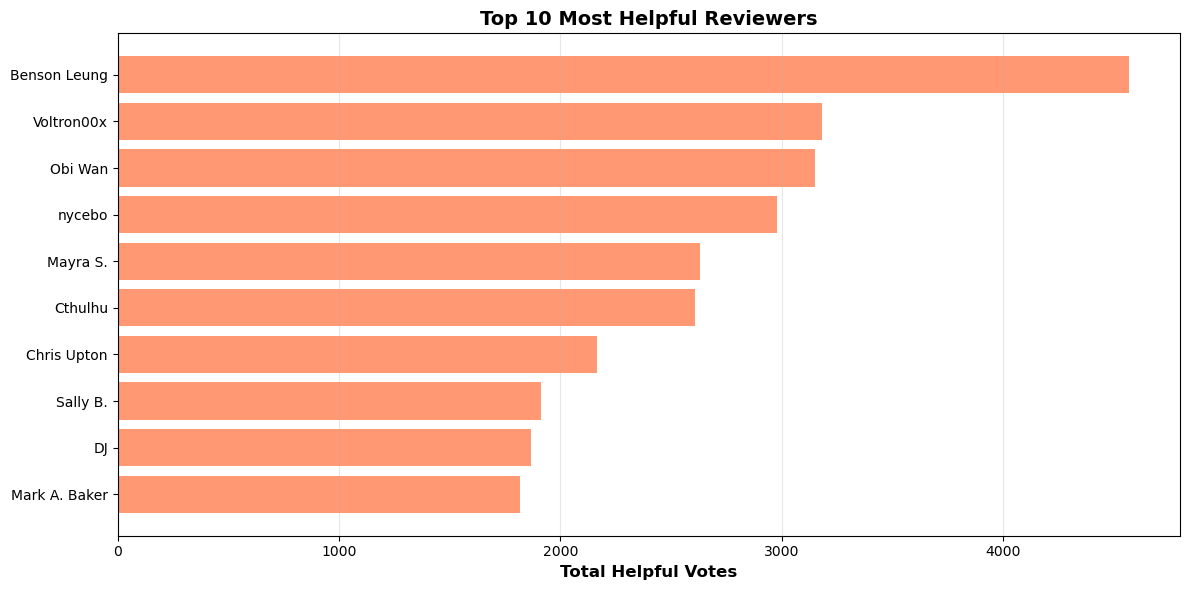


✓ Analysis completed with 191468 reviews having helpful votes


In [19]:
train_df['vote_numeric'] = pd.to_numeric(
    train_df['vote'].astype(str).str.replace(',', ''), 
    errors='coerce'
).fillna(0)

# Calculate total votes per reviewer
reviewer_votes = train_df.groupby('reviewerID').agg({
    'vote_numeric': 'sum',
    'reviewerName': 'first',

}).sort_values('vote_numeric', ascending=False)

# Rename column for clarity
reviewer_votes.columns = ['total_votes', 'reviewer_name']


top_reviewers = reviewer_votes.head(10).reset_index()

print("\nTop 10 Most Helpful Reviewers:")
print(f"{'Rank':<6}{'Reviewer Name':<30}{'Total Helpful Votes':<20}")
print("-" * 56)

for idx, row in top_reviewers.iterrows():
    name = row['reviewer_name'] if pd.notna(row['reviewer_name']) else "Anonymous"
    votes = int(row['total_votes']) if row['total_votes'] > 0 else 0
    print(f"{idx+1:<6}{name[:28]:<30}{votes:<20,}")

# Visualization
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_reviewers)), top_reviewers['total_votes'], color='coral', alpha=0.8)
plt.yticks(range(len(top_reviewers)), 
           [f"{name[:20]}" for name in top_reviewers['reviewer_name'].fillna('Anonymous')])
plt.xlabel('Total Helpful Votes', fontsize=12, fontweight='bold')
plt.title('Top 10 Most Helpful Reviewers', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Analysis completed with {len(train_df[train_df['vote_numeric'] > 0])} reviews having helpful votes")


🏆 Top 10 Most Helpful Reviewers:
Rank Reviewer Name             Total Votes     Reviews  Avg Votes    Avg Rating
--------------------------------------------------------------------------------
1    Benson Leung              4,572           29       157.7        3.5       
2    Voltron00x                3,181           9        353.4        4.9       
3    Obi Wan                   3,150           29       108.6        3.7       
4    nycebo                    2,978           2        1489.0       3.0       
5    Mayra S.                  2,631           19       138.5        4.5       
6    Cthulhu                   2,607           32       81.5         4.3       
7    Chris Upton               2,167           5        433.4        4.8       
8    Sally B.                  1,912           5        382.4        4.8       
9    DJ                        1,867           24       77.8         5.0       
10   Mark A. Baker             1,820           1        1820.0       5.0       


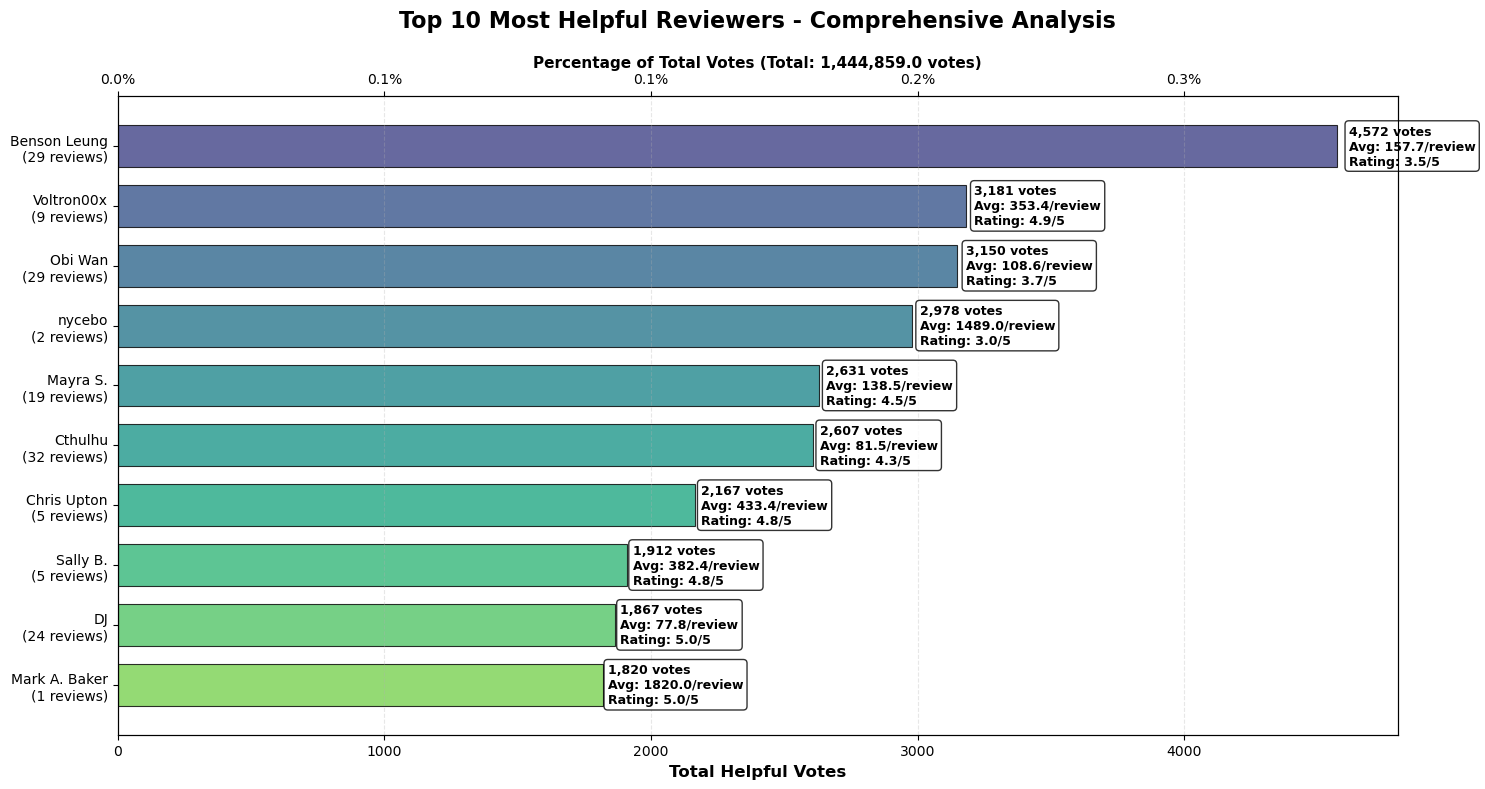


📊 Comprehensive Statistics:
Total reviewers in dataset: 321,135
Total helpful votes across all reviews: 1,444,859.0
Average votes per reviewer: 4.5
Top 10 reviewers represent: 1.9% of all helpful votes

🔍 Pattern Analysis:
Average number of reviews per top reviewer: 15.5
Average rating given by top reviewers: 4.4/5.0
📈 Top reviewers generally give positive ratings

✅ Data Quality Check:
Reviews with helpful votes: 191,468
Percentage of reviews with votes: 22.8%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert votes to numeric
train_df["vote_numeric"] = pd.to_numeric(
    train_df["vote"].astype(str).str.replace(",", "", regex=False), errors="coerce"
).fillna(0)

# Calculate total votes per reviewer with additional statistics
reviewer_stats = (
    train_df.groupby("reviewerID")
    .agg(
        {
            "vote_numeric": ["sum", "count", "mean"],
            "reviewerName": "first",
            "overall": "mean",
        }
    )
    .round(2)
)

# Flatten column names
reviewer_stats.columns = [
    "total_votes",
    "review_count",
    "avg_votes_per_review",
    "reviewer_name",
    "avg_rating",
]

# Sort by total votes and get top 10
top_reviewers = reviewer_stats.nlargest(10, "total_votes").reset_index()

print("\n🏆 Top 10 Most Helpful Reviewers:")
print("=" * 80)
print(
    f"{'Rank':<4} {'Reviewer Name':<25} {'Total Votes':<15} {'Reviews':<8} {'Avg Votes':<12} {'Avg Rating':<10}"
)
print("-" * 80)

for idx, row in top_reviewers.iterrows():
    name = (
        str(row["reviewer_name"])[:22]
        if pd.notna(row["reviewer_name"])
        else "Anonymous"
    )
    total_votes = int(row["total_votes"])
    review_count = int(row["review_count"])
    avg_votes = row["avg_votes_per_review"]
    avg_rating = row["avg_rating"]

    print(
        f"{idx+1:<4} {name:<25} {total_votes:<15,} {review_count:<8} {avg_votes:<12.1f} {avg_rating:<10.1f}"
    )

# Create one comprehensive figure
fig, ax = plt.subplots(figsize=(15, 8))

# Use viridis color scheme
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_reviewers)))

# Create horizontal bars for total votes
bars = ax.barh(
    range(len(top_reviewers)),
    top_reviewers["total_votes"],
    color=colors,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.8,
    height=0.7,
)

# Customize y-axis labels
ax.set_yticks(range(len(top_reviewers)))
reviewer_labels = []
for i, row in top_reviewers.iterrows():
    name = (
        str(row["reviewer_name"])[:20]
        if pd.notna(row["reviewer_name"])
        else "Anonymous"
    )
    review_count = int(row["review_count"])
    reviewer_labels.append(f"{name}\n({review_count} reviews)")

ax.set_yticklabels(reviewer_labels, fontsize=10)

# Customize x-axis
ax.set_xlabel("Total Helpful Votes", fontsize=12, fontweight="bold")
ax.set_title(
    "Top 10 Most Helpful Reviewers - Comprehensive Analysis",
    fontsize=16,
    fontweight="bold",
    pad=20,
)

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(
        width + width * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,} votes\n"
        f'Avg: {top_reviewers.iloc[i]["avg_votes_per_review"]:.1f}/review\n'
        f'Rating: {top_reviewers.iloc[i]["avg_rating"]:.1f}/5',
        ha="left",
        va="center",
        fontweight="bold",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

# Add grid and invert y-axis
ax.grid(axis="x", alpha=0.3, linestyle="--")
ax.invert_yaxis()

# Add a second x-axis on top to show percentage of total votes
total_all_votes = reviewer_stats["total_votes"].sum()
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xlabel(
    f"Percentage of Total Votes (Total: {total_all_votes:,} votes)",
    fontsize=11,
    fontweight="bold",
)


# Add percentage ticks
def votes_to_percent(x):
    return f"{(x/total_all_votes*100):.1f}%"


ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: votes_to_percent(x)))

plt.tight_layout()
plt.show()

# Additional statistics
print(f"\n📊 Comprehensive Statistics:")
print("=" * 50)
total_reviewers = len(reviewer_stats)
total_votes_all = reviewer_stats["total_votes"].sum()
avg_votes_per_reviewer = reviewer_stats["total_votes"].mean()

print(f"Total reviewers in dataset: {total_reviewers:,}")
print(f"Total helpful votes across all reviews: {total_votes_all:,}")
print(f"Average votes per reviewer: {avg_votes_per_reviewer:,.1f}")
print(
    f"Top 10 reviewers represent: {top_reviewers['total_votes'].sum()/total_votes_all*100:.1f}% of all helpful votes"
)

# Analysis of top reviewers pattern
print(f"\n🔍 Pattern Analysis:")
avg_reviews_top10 = top_reviewers["review_count"].mean()
avg_rating_top10 = top_reviewers["avg_rating"].mean()
print(f"Average number of reviews per top reviewer: {avg_reviews_top10:.1f}")
print(f"Average rating given by top reviewers: {avg_rating_top10:.1f}/5.0")

# Check if top reviewers tend to give positive ratings
if avg_rating_top10 > 3.5:
    print("📈 Top reviewers generally give positive ratings")
elif avg_rating_top10 < 2.5:
    print("📉 Top reviewers generally give negative ratings")
else:
    print("📊 Top reviewers give mixed ratings")

print(f"\n✅ Data Quality Check:")
print(f"Reviews with helpful votes: {len(train_df[train_df['vote_numeric'] > 0]):,}")
print(
    f"Percentage of reviews with votes: {len(train_df[train_df['vote_numeric'] > 0])/len(train_df)*100:.1f}%"
)


# ------------------------------------------------------------
# Question 4: Review Text Length Analysis
# ------------------------------------------------------------


Text length statistics:
count    838944.000000
mean        624.687384
std         684.129474
min         200.000000
25%         277.000000
50%         408.000000
75%         697.000000
max       29146.000000
Name: text_length, dtype: float64


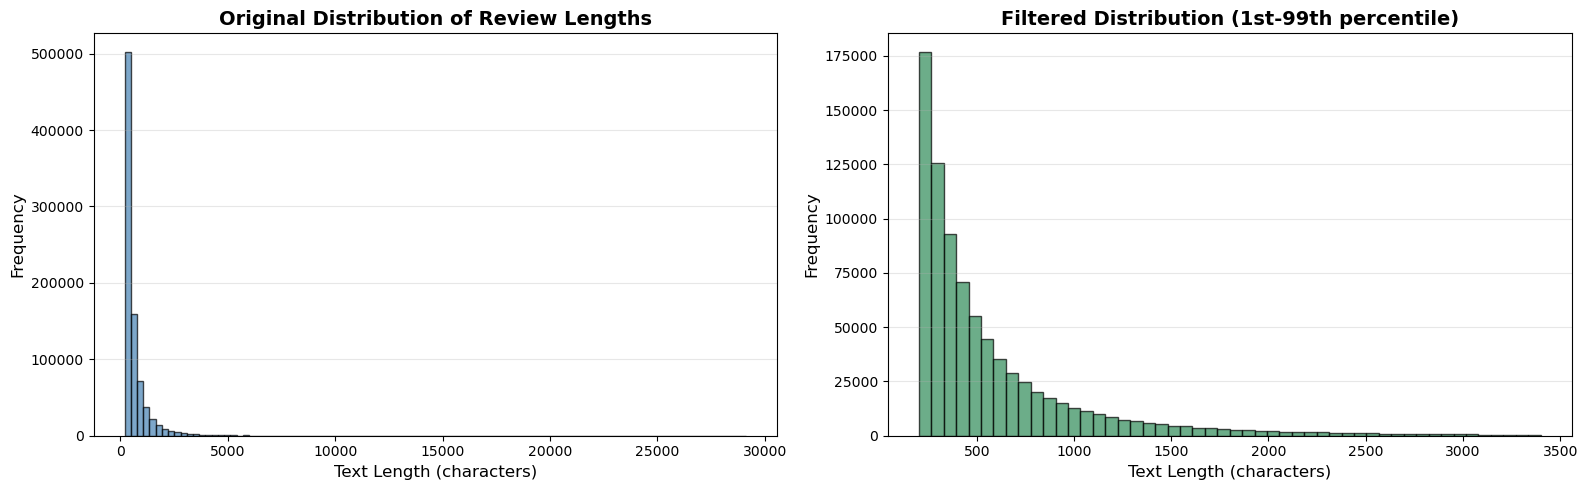

In [27]:

# Calculate text length
train_df['text_length'] = train_df['reviewText'].fillna('').apply(len)

print(f"\nText length statistics:")
print(train_df['text_length'].describe())

# Plot histogram - Original
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Original histogram
axes[0].hist(train_df['text_length'], bins=100, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Text Length (characters)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Original Distribution of Review Lengths', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Filtered histogram (remove outliers)
q1, q3 = train_df['text_length'].quantile([0.01, 0.99])
filtered_lengths = train_df[(train_df['text_length'] >= q1) & (train_df['text_length'] <= q3)]['text_length']

axes[1].hist(filtered_lengths, bins=50, color='seagreen', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Text Length (characters)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Filtered Distribution (1st-99th percentile)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

# Recommendations
print("\n💡 Modeling Recommendations:")
percentiles = train_df['text_length'].quantile([0.05, 0.25, 0.50, 0.75, 0.95])
print(f"\n5th percentile: {percentiles[0.05]:.0f} chars")
print(f"25th percentile: {percentiles[0.25]:.0f} chars")
print(f"Median: {percentiles[0.50]:.0f} chars")
print(f"75th percentile: {percentiles[0.75]:.0f} chars")
print(f"95th percentile: {percentiles[0.95]:.0f} chars")

print(f"\n✓ Recommended character limits for modeling:")
print(f"  Minimum: {max(10, percentiles[0.05]):.0f} characters")
print(f"  Maximum: {percentiles[0.95]:.0f} characters")
print(f"  (This keeps ~90% of reviews while removing very short/long outliers)")







💡 Modeling Recommendations:

5th percentile: 212 chars
25th percentile: 277 chars
Median: 408 chars
75th percentile: 697 chars
95th percentile: 1733 chars

✓ Recommended character limits for modeling:
  Minimum: 212 characters
  Maximum: 1733 characters
  (This keeps ~90% of reviews while removing very short/long outliers)


# ------------------------------------------------------------
# Question 5: Top 10 Products with Most 5-Star Ratings
# ------------------------------------------------------------

In [24]:

# Filter 5-star reviews
five_star_reviews = train_df[train_df['overall'] == 5]

# Count by product
top_5star_products = five_star_reviews.groupby('asin').size().sort_values(ascending=False).head(10)

print("\nTop 10 Products with Most 5-Star Ratings:")

# If we have product mapping, merge it
if product_mapping_df is not None and 'asin' in product_mapping_df.columns:
    result_df = pd.DataFrame({
        'asin': top_5star_products.index,
        'count_5star': top_5star_products.values
    })
    result_df = result_df.merge(product_mapping_df[['asin', 'title', 'brand']], on='asin', how='left')
    
    print(f"\n{'Rank':<6}{'Brand':<20}{'Product':<40}{'5-Star Count':<15}")
    print("-" * 81)
    for idx, row in result_df.iterrows():
        brand = row['brand'][:18] if pd.notna(row['brand']) else 'N/A'
        title = row['title'][:38] if pd.notna(row['title']) else 'N/A'
        print(f"{idx+1:<6}{brand:<20}{title:<40}{row['count_5star']:<15}")
else:
    print("\n⚠️  Product mapping not available. Showing ASIN codes:")
    print(f"\n{'Rank':<6}{'ASIN':<15}{'5-Star Count':<15}")
    print("-" * 36)
    for idx, (asin, count) in enumerate(top_5star_products.items(), 1):
        print(f"{idx:<6}{asin:<15}{count:<15}")



Top 10 Products with Most 5-Star Ratings:

Rank  Brand               Product                                 5-Star Count   
---------------------------------------------------------------------------------
1     Cambridge Soundwor  OontZ Angle 3 Enhanced Stereo Edition   1163           
2     NETGEAR             NETGEAR N300 WiFi Range Extender (EX27  659            
3     Roku                Roku Streaming Stick (3600R) - HD Stre  600            
4     StarTech            StarTech USB 2.0 to SATA IDE Adapter (  598            
5     Logitech            Logitech M570 Wireless Trackball Mouse  552            
6     Samsung             Samsung 850 EVO 500GB 2.5-Inch SATA II  529            
7     Asus                ASUS Tri-Band Gigabit (AC3200) WiFi Ro  471            
8     VideoSecu           VideoSecu ML531BE TV Wall Mount for Mo  448            
9     Arlo Technologies,  Arlo - Wireless Home Security Camera S  433            
10    Samsung             Samsung 850 EVO 250GB 2.5-In


# ------------------------------------------------------------
# Question 6: Top 10 Brands by Review Count & Average Rating
# ------------------------------------------------------------


🏆 Top 10 Brands (by Review Count) with Average Ratings
Rank Brand                Avg Rating   Reviews    Unique     Std Dev    Range       
-------------------------------------------------------------------------------------
1    Anker                4.24         9860       9196       1.20       1-5       
2    AmazonBasics         4.20         13213      11584      1.21       1-5       
3    Sabrent              4.03         7320       6784       1.37       1-5       
4    SanDisk              3.96         8400       7695       1.46       1-5       
5    Logitech             3.95         17066      14624      1.35       1-5       
6    Samsung              3.94         15409      14059      1.44       1-5       
7    Sony                 3.94         12436      10479      1.38       1-5       
8    TP-LINK              3.93         9773       8199       1.44       1-5       
9    Asus                 3.86         11928      10726      1.46       1-5       
10   NETGEAR              

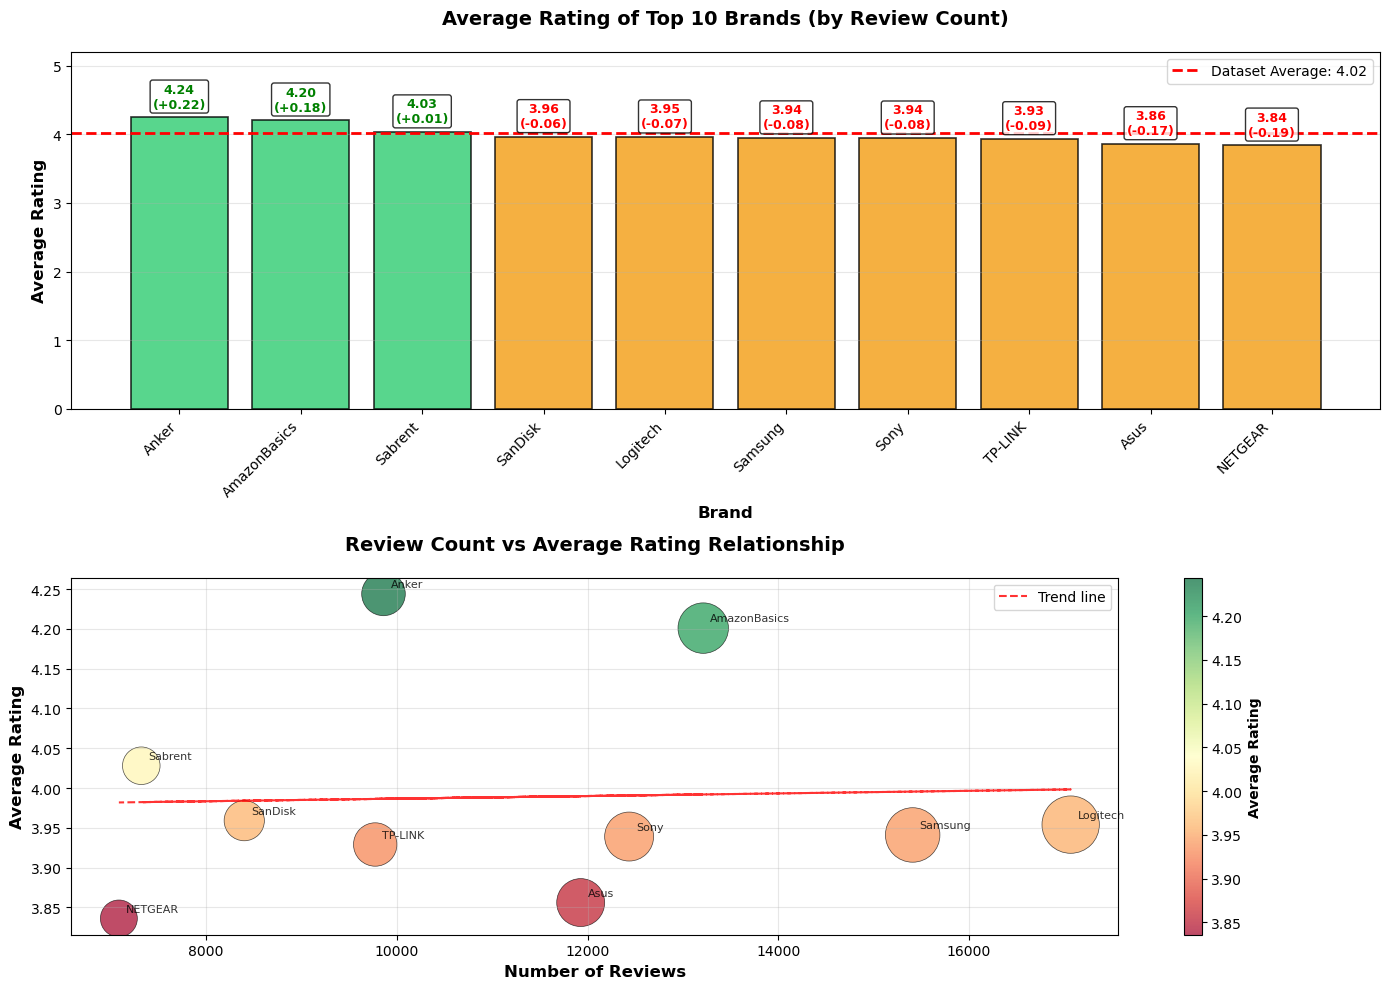


📊 Additional Analysis:
Overall dataset average rating: 4.02
Brand with highest average rating: Anker (4.24)
Brand with most reviews: Logitech (17,066 reviews)
Total reviews analyzed: 112,490
Correlation between review count and average rating: 0.041
📊 Weak correlation: No strong relationship between review count and rating


In [26]:
if product_mapping_df is not None and 'brand' in product_mapping_df.columns:
    # Merge product info with reviews
    df_with_brands = train_df.merge(product_mapping_df[['asin', 'brand']], on='asin', how='left')
    
    # Clean brand names - handle missing values
    df_with_brands['brand'] = df_with_brands['brand'].fillna('Unknown Brand')
    
    # Find top 10 brands by review count
    brand_review_counts = df_with_brands['brand'].value_counts()
    top_brands_by_count = brand_review_counts.head(10).index
    
    # Calculate comprehensive statistics for these brands
    brand_stats = df_with_brands[df_with_brands['brand'].isin(top_brands_by_count)].groupby('brand').agg({
        'overall': ['mean', 'count', 'std', 'min', 'max'],
        'reviewerID': 'nunique'  # Count unique reviewers
    }).round(3)
    
    # Flatten column names
    brand_stats.columns = ['avg_rating', 'review_count', 'rating_std', 'min_rating', 'max_rating', 'unique_reviewers']
    
    # Sort by average rating (primary) and review count (secondary)
    brand_stats = brand_stats.sort_values(['avg_rating', 'review_count'], ascending=[False, False])
    
    # Calculate overall dataset average
    overall_avg_rating = train_df['overall'].mean()
    
    print("\n🏆 Top 10 Brands (by Review Count) with Average Ratings")
    print("=" * 85)
    print(f"{'Rank':<4} {'Brand':<20} {'Avg Rating':<12} {'Reviews':<10} {'Unique':<10} {'Std Dev':<10} {'Range':<12}")
    print("-" * 85)
    
    for idx, (brand, row) in enumerate(brand_stats.iterrows(), 1):
        brand_name = str(brand)[:18] + "..." if len(str(brand)) > 18 else str(brand)
        print(f"{idx:<4} {brand_name:<20} {row['avg_rating']:<12.2f} {int(row['review_count']):<10} "
              f"{int(row['unique_reviewers']):<10} {row['rating_std']:<10.2f} "
              f"{int(row['min_rating'])}-{int(row['max_rating']):<8}")

    # Enhanced Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Color coding based on rating
    colors = []
    for rating in brand_stats['avg_rating']:
        if rating >= 4.0:
            colors.append('#2ecc71')  # Green for high ratings
        elif rating >= 3.0:
            colors.append('#f39c12')  # Orange for medium ratings
        else:
            colors.append('#e74c3c')  # Red for low ratings
    
    # Plot 1: Average ratings with enhanced styling
    bars = ax1.bar(range(len(brand_stats)), brand_stats['avg_rating'], 
                   color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
    
    ax1.set_xlabel('Brand', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Average Rating', fontsize=12, fontweight='bold')
    ax1.set_title('Average Rating of Top 10 Brands (by Review Count)', 
                  fontsize=14, fontweight='bold', pad=20)
    ax1.set_xticks(range(len(brand_stats)))
    ax1.set_xticklabels([str(brand)[:15] + "..." if len(str(brand)) > 15 else str(brand) 
                        for brand in brand_stats.index], rotation=45, ha='right')
    ax1.set_ylim([0, 5.2])
    
    # Add overall average line and custom grid
    ax1.axhline(y=overall_avg_rating, color='red', linestyle='--', linewidth=2, 
                label=f'Dataset Average: {overall_avg_rating:.2f}')
    ax1.grid(axis='y', alpha=0.3, linestyle='-')
    
    # Add value labels on bars with rating comparison
    for i, bar in enumerate(bars):
        height = bar.get_height()
        diff_from_avg = height - overall_avg_rating
        color = 'green' if diff_from_avg > 0 else 'red' if diff_from_avg < 0 else 'black'
        
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.2f}\n({diff_from_avg:+.2f})', 
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=color, bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
    
    ax1.legend()
    
    # Plot 2: Review count vs Average rating scatter plot
    scatter = ax2.scatter(brand_stats['review_count'], brand_stats['avg_rating'],
                         s=brand_stats['review_count']/10,  # Size based on review count
                         c=brand_stats['avg_rating'], 
                         cmap='RdYlGn', 
                         alpha=0.7, 
                         edgecolors='black', 
                         linewidth=0.5)
    
    ax2.set_xlabel('Number of Reviews', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Average Rating', fontsize=12, fontweight='bold')
    ax2.set_title('Review Count vs Average Rating Relationship', 
                  fontsize=14, fontweight='bold', pad=20)
    ax2.grid(alpha=0.3)
    
    # Add brand labels to scatter points
    for i, (brand, row) in enumerate(brand_stats.iterrows()):
        ax2.annotate(str(brand)[:12], 
                    (row['review_count'], row['avg_rating']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.8)
    
    # Add colorbar for scatter plot
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Average Rating', fontweight='bold')
    
    # Add trend line
    z = np.polyfit(brand_stats['review_count'], brand_stats['avg_rating'], 1)
    p = np.poly1d(z)
    ax2.plot(brand_stats['review_count'], p(brand_stats['review_count']), 
             "r--", alpha=0.8, label=f'Trend line')
    
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Additional analysis
    print(f"\n📊 Additional Analysis:")
    print("=" * 50)
    print(f"Overall dataset average rating: {overall_avg_rating:.2f}")
    print(f"Brand with highest average rating: {brand_stats.index[0]} ({brand_stats['avg_rating'].iloc[0]:.2f})")
    print(f"Brand with most reviews: {brand_review_counts.index[0]} ({brand_review_counts.iloc[0]:,} reviews)")
    print(f"Total reviews analyzed: {brand_stats['review_count'].sum():,}")
    
    # Check correlation between review count and rating
    correlation = brand_stats['review_count'].corr(brand_stats['avg_rating'])
    print(f"Correlation between review count and average rating: {correlation:.3f}")
    
    if correlation > 0.3:
        print("📈 Positive correlation: Brands with more reviews tend to have higher ratings")
    elif correlation < -0.3:
        print("📉 Negative correlation: Brands with more reviews tend to have lower ratings")
    else:
        print("📊 Weak correlation: No strong relationship between review count and rating")

else:
    print("\n⚠️  Product mapping not available or 'brand' column not found. Cannot perform brand analysis.")
    if product_mapping_df is not None:
        print(f"Available columns in product_mapping_df: {list(product_mapping_df.columns)}")